

- **추상적 요약**: seq2seq + attention 모델이 새로운 문장을 생성
- **추출적 요약**: Summa가 원문 문장 중 중요한 문장을 골라냄





1. 뉴스 데이터셋을 불러오고 `text`, `headlines` col 확인 
2. 중복, 결측치, 빈 문자열, 길이 기준 적용 전처리 
3. text는 불용어 제거를 적용하고, headlines는 제거 X
5. 과적합 판단을 위해 train vs val loss 시각화 
6. 실제 headline vs 모델 생성 추상적 요약 vs Summa 추출적 요약

---   
데이터 불러오기

In [1]:
import os
from pathlib import Path
from collections import Counter
import re

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from bs4 import BeautifulSoup
from tqdm import tqdm

import nltk
from nltk.corpus import stopwords

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 0)


def display_full_dataframe(df):
    """긴 text/headline 컬럼이 ...로 잘리지 않고, <UNK>도 문자 그대로 보이게 표시합니다."""
    return display(
        df.style.format(escape="html").set_properties(**{
            "white-space": "pre-wrap",
            "text-align": "left",
            "vertical-align": "top",
        })
    )

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("현재 작업 디렉토리:", os.getcwd())
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

현재 작업 디렉토리: /home/thkim0/github/AIFFEL_quest_rs/Exploration/Ex07
PyTorch version: 2.0.1+cu118
CUDA available: True


In [2]:
path_candidates = [
    Path("Ex07/news_summary_more.csv"),
    Path("news_summary_more.csv"),
    Path("AIFFEL_quest_rs/Exploration/Ex07/news_summary_more.csv"),
]

data_path = next((path for path in path_candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("news_summary_more.csv 파일을 찾지 못했습니다. Ex07 폴더 위치를 확인해 주세요.")

print("사용할 데이터 경로:", data_path)
data = pd.read_csv(data_path)
print("전체 샘플 수:", len(data))
print("컬럼:", data.columns.tolist())

display_full_dataframe(data.head())

사용할 데이터 경로: news_summary_more.csv
전체 샘플 수: 98401
컬럼: ['headlines', 'text']


,headlines,text
0,upGrad learner switches to career in ML & Al with 90% salary hike,"Saurav Kant, an alumnus of upGrad and IIIT-B's PG Program in Machine learning and Artificial Intelligence, was a Sr Systems Engineer at Infosys with almost 5 years of work experience. The program and upGrad's 360-degree career support helped him transition to a Data Scientist at Tech Mahindra with 90% salary hike. upGrad's Online Power Learning has powered 3 lakh+ careers."
1,Delhi techie wins free food from Swiggy for one year on CRED,"Kunal Shah's credit card bill payment platform, CRED, gave users a chance to win free food from Swiggy for one year. Pranav Kaushik, a Delhi techie, bagged this reward after spending 2000 CRED coins. Users get one CRED coin per rupee of bill paid, which can be used to avail rewards from brands like Ixigo, BookMyShow, UberEats, Cult.Fit and more."
2,New Zealand end Rohit Sharma-led India's 12-match winning streak,"New Zealand defeated India by 8 wickets in the fourth ODI at Hamilton on Thursday to win their first match of the five-match ODI series. India lost an international match under Rohit Sharma's captaincy after 12 consecutive victories dating back to March 2018. The match witnessed India getting all out for 92, their seventh lowest total in ODI cricket history."
3,Aegon life iTerm insurance plan helps customers save tax,"With Aegon Life iTerm Insurance plan, customers can enjoy tax benefits on your premiums paid and save up to â¹46,800^ on taxes. The plan provides life cover up to the age of 100 years. Also, customers have options to insure against Critical Illnesses, Disability and Accidental Death Benefit Rider with a life cover up to the age of 80 years."
4,"Have known Hirani for yrs, what if MeToo claims are not true: Sonam","Speaking about the sexual harassment allegations against Rajkumar Hirani, Sonam Kapoor said, ""I've known Hirani for many years...What if it's not true, the [#MeToo] movement will get derailed."" ""In the #MeToo movement, I always believe a woman. But in this case, we need to reserve our judgment,"" she added. Hirani has been accused by an assistant who worked in 'Sanju'."


In [3]:
required_columns = ["text", "headlines"]
missing_columns = [col for col in required_columns if col not in data.columns]
if missing_columns:
    raise ValueError(f"필수 컬럼이 없습니다: {missing_columns}")

data = data[required_columns].copy()
display_full_dataframe(data.sample(5, random_state=SEED))

,text,headlines
32571,"Students in Karnataka will get extra marks if their parents cast votes in the upcoming assembly elections, the Associated Management of Primary and Secondary Schools has announced. The ""Encouraging Marks"" will be added in the 2018-19 academic year. The association said, ""After casting their votes, parents can visit member schools...and confirm that they voted by showing the indelible ink mark.""",K'taka students to get extra marks if parents vote in polls
35184,"Syrian anti-aircraft defences on Monday shot down missiles over two air bases, Syria's state media said. The missiles targeted Shayrat air base in the Homs province and another base northeast of the capital Damascus. This comes days after the US, UK and France launched air strikes on Syrian chemical weapons facilities in retaliation for the alleged chemical attack in Douma.",Syria shoots down missiles fired at two air bases
59997,"A Dinosaur-like creature's fossil was found during an excavation on Sunday in Uttarakhand's Jaspur, a small city 110 km from Nainital. The fossil's hind legs measure around 29 cm while the tail is around 5 cm long. Found at an abandoned electricity department land, the authorities would be sending the remains to Dehradun-based Wildlife Institute of India for further investigation.",Dinosaur-like animal's fossil found in Uttarakhand
64665,"The Uttar Pradesh government is planning to form a 'UP Muslim Waqf Board' by merging the separate Shia and Sunni Waqf boards to prevent wastage of funds, Minister of State for Waqf Mohsin Raza said. The merged Waqf board will have members from both the communities and its Chairman will be selected from among them, he added.","UP may merge Shia, Sunni Waqf boards to prevent fund wastage"
15343,"Egyptian activist-actress Amal Fathy has been given a sentence of two years on charges of ""spreading false news"" for uploading a video on Facebook, wherein she alleged that she faced sexual harassment at a bank. Fathy was charged with ""disseminating a video on social media to publicly incite overthrowing the government"". She has already spent over 140 days in prison.",Egypt actress gets 2 yrs jail for 'fake news' on sexual harassment


---  
데이터 확인 및 결측치/중복 제거

추상적 요약에서는 text가 encoder 입력, headlines가 decoder 정답 --> 비어 있으면 사용 불가 

In [4]:
print("text 고유 샘플 수:", data["text"].nunique())
print("headlines 고유 샘플 수:", data["headlines"].nunique())
print("\n결측치 개수")
print(data.isnull().sum())

text 고유 샘플 수: 98360
headlines 고유 샘플 수: 98280

결측치 개수
text         0
headlines    0
dtype: int64


In [5]:
original_count = len(data)
data.drop_duplicates(subset=["text"], inplace=True)
data.dropna(axis=0, inplace=True)

print("중복/결측 제거 전 샘플 수:", original_count)
print("중복/결측 제거 후 샘플 수:", len(data))
print(data.isnull().sum())

# 전처리 전 원문을 보존합니다.
# 추상적 요약 비교표에서는 정수 인코딩 복원값이 아니라 이 raw 문자열을 사용합니다.
data["raw_text"] = data["text"].astype(str)
data["raw_headlines"] = data["headlines"].astype(str)

# Summa 추출적 요약은 문장 경계가 살아 있는 원문이 더 적합합니다.
raw_text_for_extractive = data["raw_text"].copy()

중복/결측 제거 전 샘플 수: 98401
중복/결측 제거 후 샘플 수: 98360
text         0
headlines    0
dtype: int64


---  
 텍스트 정규화 및 전처리

- 소문자화
- HTML 태그 제거
- 괄호 기호만 제거, 괄호 안 내용은 보존
- 축약형 정규화
- 특수문자 제거
- 불필요한 공백 제거
- 빈 문자열 제거

불용어 처리

- text: 원문이 상대적으로 길기 때문에 일부 불용어를 제거해도 핵심 단어가 남을 가능성이 큼 -> 제거 
- headlines: 짧고 정보 밀도가 높기 때문에 불용어 제거 X 

In [6]:
fallback_stopwords = {
    "a", "an", "the", "and", "or", "but", "if", "while", "is", "am", "are", "was", "were",
    "be", "been", "being", "to", "of", "in", "on", "for", "with", "by", "as", "at",
    "from", "this", "that", "these", "those", "it", "its", "he", "she", "they", "we",
    "you", "i", "my", "your", "his", "her", "their", "our", "have", "has", "had",
    "do", "does", "did", "will", "would", "can", "could", "should", "may", "might",
}

try:
    english_stopwords = set(stopwords.words("english"))
except LookupError:
    download_ok = nltk.download("stopwords", quiet=True)
    if download_ok:
        english_stopwords = set(stopwords.words("english"))
    else:
        english_stopwords = fallback_stopwords
        print("NLTK stopwords를 내려받지 못해 fallback 불용어 목록을 사용합니다.")

meaning_sensitive_words = {"not", "no", "before", "after", "against"}
text_stopwords = english_stopwords - meaning_sensitive_words

print("전체 불용어 개수:", len(english_stopwords))
print("text에서 제거할 불용어 개수:", len(text_stopwords))
print("의미 보존을 위해 남기는 단어:", sorted(meaning_sensitive_words))


전체 불용어 개수: 198
text에서 제거할 불용어 개수: 193
의미 보존을 위해 남기는 단어: ['after', 'against', 'before', 'no', 'not']


In [7]:
contractions = {
    "ain't": "is not", "aren't": "are not", "can't": "cannot", "can't've": "cannot have",
    "'cause": "because", "could've": "could have", "couldn't": "could not",
    "couldn't've": "could not have", "didn't": "did not", "doesn't": "does not",
    "don't": "do not", "hadn't": "had not", "hadn't've": "had not have",
    "hasn't": "has not", "haven't": "have not", "he'd": "he would",
    "he'd've": "he would have", "he'll": "he will", "he'll've": "he will have",
    "he's": "he is", "how'd": "how did", "how'll": "how will", "how's": "how is",
    "i'd": "i would", "i'd've": "i would have", "i'll": "i will",
    "i'll've": "i will have", "i'm": "i am", "i've": "i have", "isn't": "is not",
    "it'd": "it would", "it'd've": "it would have", "it'll": "it will",
    "it'll've": "it will have", "it's": "it is", "let's": "let us",
    "ma'am": "madam", "mayn't": "may not", "might've": "might have",
    "mightn't": "might not", "must've": "must have", "mustn't": "must not",
    "needn't": "need not", "o'clock": "of the clock", "oughtn't": "ought not",
    "shan't": "shall not", "she'd": "she would", "she'll": "she will",
    "she's": "she is", "should've": "should have", "shouldn't": "should not",
    "that's": "that is", "there's": "there is", "they'd": "they would",
    "they'll": "they will", "they're": "they are", "they've": "they have",
    "wasn't": "was not", "we'd": "we would", "we'll": "we will",
    "we're": "we are", "we've": "we have", "weren't": "were not",
    "what's": "what is", "when's": "when is", "where's": "where is",
    "who's": "who is", "why's": "why is", "will've": "will have",
    "won't": "will not", "won't've": "will not have", "would've": "would have",
    "wouldn't": "would not", "y'all": "you all", "you're": "you are",
    "you've": "you have", "you'll": "you will", "you'd": "you would",
}

print("정규화 사전 크기:", len(contractions))

정규화 사전 크기: 78


In [8]:
def preprocess_sentence(sentence, remove_stopwords=True):
    sentence = str(sentence).lower()
    sentence = BeautifulSoup(sentence, "html.parser").get_text(" ")
    sentence = re.sub(r"[()]", " ", sentence)
    sentence = re.sub(r'"', " ", sentence)
    sentence = " ".join(contractions.get(token, token) for token in sentence.split())
    sentence = re.sub(r"'s\b", "", sentence)
    sentence = re.sub(r"[^a-zA-Z0-9]", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence).strip()

    tokens = sentence.split()
    if remove_stopwords:
        tokens = [word for word in tokens if word not in text_stopwords and len(word) > 1]
    else:
        tokens = [word for word in tokens if len(word) > 0]
    return " ".join(tokens)

sample_text = "The company isn't against the policy before 2025.<br />It won't appeal."
sample_headline = "Company isn't against policy before 2025"

print("text 전처리 예시:", preprocess_sentence(sample_text, remove_stopwords=True))
print("headlines 전처리 예시:", preprocess_sentence(sample_headline, remove_stopwords=False))

text 전처리 예시: company not against policy before 2025 not appeal
headlines 전처리 예시: company is not against policy before 2025


In [9]:
tqdm.pandas()

clean_text = [
    preprocess_sentence(sentence, remove_stopwords=True)
    for sentence in tqdm(data["text"], desc="Preprocess text")
]
clean_headlines = [
    preprocess_sentence(sentence, remove_stopwords=False)
    for sentence in tqdm(data["headlines"], desc="Preprocess headlines")
]

data["text"] = clean_text
data["headlines"] = clean_headlines

data.replace("", np.nan, inplace=True)
print(data.isnull().sum())

data.dropna(axis=0, inplace=True)
print("빈 문자열 제거 후 샘플 수:", len(data))

display_full_dataframe(data.head())

Preprocess headlines: 100%|██████████| 98360/98360 [00:02<00:00, 38950.24it/s]

text             0
headlines        0
raw_text         0
raw_headlines    0
dtype: int64
빈 문자열 제거 후 샘플 수: 98360


,text,headlines,raw_text,raw_headlines
0,saurav kant alumnus upgrad iiit pg program machine learning artificial intelligence sr systems engineer infosys almost years work experience program upgrad 360 degree career support helped transition data scientist tech mahindra 90 salary hike upgrad online power learning powered lakh careers,upgrad learner switches to career in ml al with 90 salary hike,"Saurav Kant, an alumnus of upGrad and IIIT-B's PG Program in Machine learning and Artificial Intelligence, was a Sr Systems Engineer at Infosys with almost 5 years of work experience. The program and upGrad's 360-degree career support helped him transition to a Data Scientist at Tech Mahindra with 90% salary hike. upGrad's Online Power Learning has powered 3 lakh+ careers.",upGrad learner switches to career in ML & Al with 90% salary hike
1,kunal shah credit card bill payment platform cred gave users chance win free food swiggy one year pranav kaushik delhi techie bagged reward after spending 2000 cred coins users get one cred coin per rupee bill paid used avail rewards brands like ixigo bookmyshow ubereats cult fit,delhi techie wins free food from swiggy for one year on cred,"Kunal Shah's credit card bill payment platform, CRED, gave users a chance to win free food from Swiggy for one year. Pranav Kaushik, a Delhi techie, bagged this reward after spending 2000 CRED coins. Users get one CRED coin per rupee of bill paid, which can be used to avail rewards from brands like Ixigo, BookMyShow, UberEats, Cult.Fit and more.",Delhi techie wins free food from Swiggy for one year on CRED
2,new zealand defeated india wickets fourth odi hamilton thursday win first match five match odi series india lost international match rohit sharma captaincy after 12 consecutive victories dating back march 2018 match witnessed india getting 92 seventh lowest total odi cricket history,new zealand end rohit sharma led india 12 match winning streak,"New Zealand defeated India by 8 wickets in the fourth ODI at Hamilton on Thursday to win their first match of the five-match ODI series. India lost an international match under Rohit Sharma's captaincy after 12 consecutive victories dating back to March 2018. The match witnessed India getting all out for 92, their seventh lowest total in ODI cricket history.",New Zealand end Rohit Sharma-led India's 12-match winning streak
3,aegon life iterm insurance plan customers enjoy tax benefits premiums paid save 46 800 taxes plan provides life cover age 100 years also customers options insure against critical illnesses disability accidental death benefit rider life cover age 80 years,aegon life iterm insurance plan helps customers save tax,"With Aegon Life iTerm Insurance plan, customers can enjoy tax benefits on your premiums paid and save up to â¹46,800^ on taxes. The plan provides life cover up to the age of 100 years. Also, customers have options to insure against Critical Illnesses, Disability and Accidental Death Benefit Rider with a life cover up to the age of 80 years.",Aegon life iTerm insurance plan helps customers save tax
4,speaking sexual harassment allegations against rajkumar hirani sonam kapoor said known hirani many years not true metoo movement get derailed metoo movement always believe woman case need reserve judgment added hirani accused assistant worked sanju,have known hirani for yrs what if metoo claims are not true sonam,"Speaking about the sexual harassment allegations against Rajkumar Hirani, Sonam Kapoor said, ""I've known Hirani for many years...What if it's not true, the [#MeToo] movement will get derailed."" ""In the #MeToo movement, I always believe a woman. But in this case, we need to reserve our judgment,"" she added. Hirani has been accused by an assistant who worked in 'Sanju'.","Have known Hirani for yrs, what if MeToo claims are not true: Sonam"


---   
 길이 분포 확인 및 최대 길이 설정  
뉴스 데이터는 원문이 대체로 60단어 내외이고 headline은 10단어 안팎입니다. 기본값은 다음처럼 둡니다.

- text_max_len = 60
- summary_max_len = 14


text 최소 길이: 1
text 최대 길이: 60
text 평균 길이: 37.33331638877593
headlines 최소 길이: 1
headlines 최대 길이: 18
headlines 평균 길이: 9.886518910126068


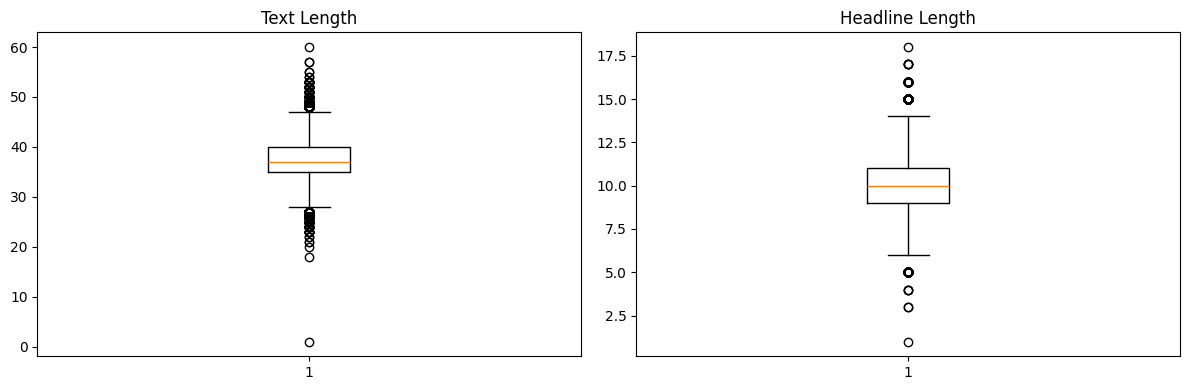

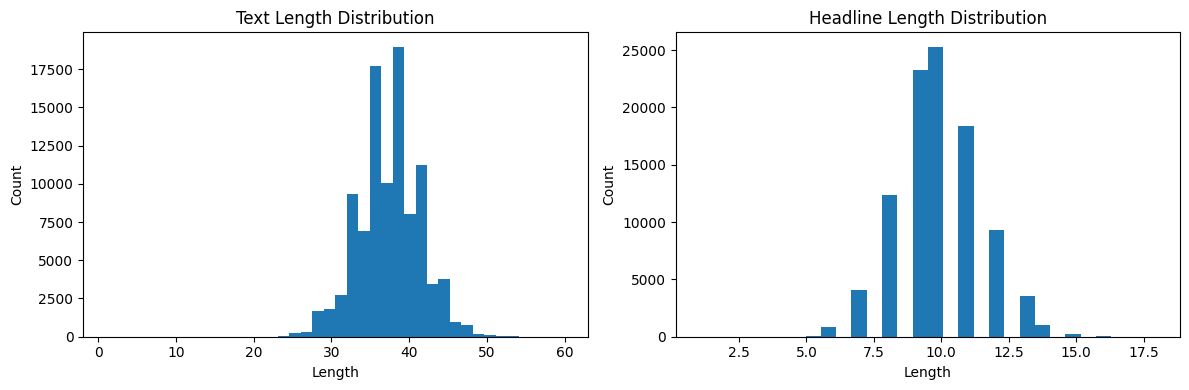

In [10]:
text_len = [len(sentence.split()) for sentence in data["text"]]
summary_len = [len(sentence.split()) for sentence in data["headlines"]]

print("text 최소 길이:", np.min(text_len))
print("text 최대 길이:", np.max(text_len))
print("text 평균 길이:", np.mean(text_len))
print("headlines 최소 길이:", np.min(summary_len))
print("headlines 최대 길이:", np.max(summary_len))
print("headlines 평균 길이:", np.mean(summary_len))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.boxplot(text_len)
plt.title("Text Length")
plt.subplot(1, 2, 2)
plt.boxplot(summary_len)
plt.title("Headline Length")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(text_len, bins=40)
plt.xlabel("Length")
plt.ylabel("Count")
plt.title("Text Length Distribution")
plt.subplot(1, 2, 2)
plt.hist(summary_len, bins=30)
plt.xlabel("Length")
plt.ylabel("Count")
plt.title("Headline Length Distribution")
plt.tight_layout()
plt.show()

In [11]:
text_max_len = 60
summary_max_len = 14
headline_max_len = summary_max_len - 1

def below_threshold_len(max_len, lengths):
    count = sum(length <= max_len for length in lengths)
    ratio = count / len(lengths)
    print(f"전체 샘플 중 길이가 {max_len} 이하인 샘플 비율: {ratio:.4f}")

below_threshold_len(text_max_len, text_len)
below_threshold_len(headline_max_len, summary_len)

전체 샘플 중 길이가 60 이하인 샘플 비율: 1.0000
전체 샘플 중 길이가 13 이하인 샘플 비율: 0.9872


In [12]:
before_filter_count = len(data)
data = data[data["text"].apply(lambda x: len(x.split()) <= text_max_len)]
data = data[data["headlines"].apply(lambda x: len(x.split()) <= headline_max_len)]

data = data.copy()
print("길이 기준 적용 전 샘플 수:", before_filter_count)
print("길이 기준 적용 후 샘플 수:", len(data))

길이 기준 적용 전 샘플 수: 98360
길이 기준 적용 후 샘플 수: 97097


정수 인코딩 & 패딩

신경망은 문자열을 직접 계산할 수 없기 때문에 단어를 정수 index로 바꿉니다. 이 과정이 vocabulary 생성과 정수 인코딩입니다.

- `src_vocab`: encoder 입력인 `text`용 단어 사전
- `tar_vocab`: decoder 입력/정답인 `headlines`용 단어 사전
- `<PAD>`: padding 토큰, index 0
- `<UNK>`: vocabulary에 없는 단어
- `sostoken`: decoder가 요약 생성을 시작할 때 받는 토큰
- `eostoken`: decoder가 요약 생성을 끝낼 때 예측해야 하는 토큰

In [13]:
data["decoder_input"] = data["headlines"].apply(lambda x: "sostoken " + x)
data["decoder_target"] = data["headlines"].apply(lambda x: x + " eostoken")

encoder_texts = data["text"].tolist()
decoder_input_texts = data["decoder_input"].tolist()
decoder_target_texts = data["decoder_target"].tolist()
raw_texts = data["raw_text"].tolist()
raw_headline_texts = data["raw_headlines"].tolist()

(
    encoder_input_train,
    encoder_input_val,
    decoder_input_train,
    decoder_input_val,
    decoder_target_train,
    decoder_target_val,
    raw_text_train,
    raw_text_val,
    raw_headlines_train,
    raw_headlines_val,
) = train_test_split(
    encoder_texts,
    decoder_input_texts,
    decoder_target_texts,
    raw_texts,
    raw_headline_texts,
    test_size=0.2,
    random_state=SEED,
    shuffle=True,
)

print("훈련 샘플 수:", len(encoder_input_train))
print("검증 샘플 수:", len(encoder_input_val))
print("raw 검증 원문 수:", len(raw_text_val))
print("raw 검증 headline 수:", len(raw_headlines_val))

훈련 샘플 수: 77677
검증 샘플 수: 19420
raw 검증 원문 수: 19420
raw 검증 headline 수: 19420


In [14]:
def basic_tokenizer(text):
    return str(text).split()


def build_vocab(texts, vocab_size, tokenizer, special_tokens=None):
    vocab = {"<PAD>": 0, "<UNK>": 1}
    if special_tokens is not None:
        for token in special_tokens:
            if token not in vocab:
                vocab[token] = len(vocab)

    word_counter = Counter()
    for text in texts:
        word_counter.update(tokenizer(text))

    for word, _ in word_counter.most_common():
        if word not in vocab:
            vocab[word] = len(vocab)
        if len(vocab) >= vocab_size:
            break
    return vocab


def vocab_statistics(texts, tokenizer, threshold):
    word_counter = Counter()
    for text in texts:
        word_counter.update(tokenizer(text))

    total_cnt = len(word_counter)
    total_freq = sum(word_counter.values())
    rare_cnt = sum(1 for count in word_counter.values() if count < threshold)
    rare_freq = sum(count for count in word_counter.values() if count < threshold)

    print("단어 집합 크기:", total_cnt)
    print(f"등장 빈도가 {threshold - 1}회 이하인 희귀 단어 수:", rare_cnt)
    print("희귀 단어 비율:", round(rare_cnt / total_cnt * 100, 2) if total_cnt else 0)
    print("전체 등장 빈도 중 희귀 단어 비율:", round(rare_freq / total_freq * 100, 2) if total_freq else 0)

print("[text vocabulary statistics]")
vocab_statistics(encoder_input_train, basic_tokenizer, threshold=7)
print("\n[headline vocabulary statistics]")
vocab_statistics(decoder_input_train, basic_tokenizer, threshold=6)

[text vocabulary statistics]
단어 집합 크기: 72501
등장 빈도가 6회 이하인 희귀 단어 수: 49456
희귀 단어 비율: 68.21
전체 등장 빈도 중 희귀 단어 비율: 3.48

[headline vocabulary statistics]
단어 집합 크기: 31853
등장 빈도가 5회 이하인 희귀 단어 수: 21102
희귀 단어 비율: 66.25
전체 등장 빈도 중 희귀 단어 비율: 4.78


In [15]:
src_vocab_limit = 30000
tar_vocab_limit = 12000

src_vocab = build_vocab(encoder_input_train, src_vocab_limit, basic_tokenizer)
tar_vocab = build_vocab(
    decoder_input_train + decoder_target_train,
    tar_vocab_limit,
    basic_tokenizer,
    special_tokens=["sostoken", "eostoken"],
)

src_vocab_size = len(src_vocab)
tar_vocab_size = len(tar_vocab)

src_index_to_word = {idx: word for word, idx in src_vocab.items()}
tar_word_to_index = tar_vocab
tar_index_to_word = {idx: word for word, idx in tar_vocab.items()}

print("src_vocab_size:", src_vocab_size)
print("tar_vocab_size:", tar_vocab_size)
print("sostoken index:", tar_word_to_index["sostoken"])
print("eostoken index:", tar_word_to_index["eostoken"])

src_vocab_size: 30000
tar_vocab_size: 12000
sostoken index: 2
eostoken index: 3


In [16]:
def texts_to_sequences(texts, vocab, tokenizer):
    unk_index = vocab["<UNK>"]
    return [[vocab.get(token, unk_index) for token in tokenizer(text)] for text in texts]


def pad_sequences(sequences, max_len, padding_value=0):
    padded = np.full((len(sequences), max_len), padding_value, dtype=np.int64)
    for row_idx, sequence in enumerate(sequences):
        sequence = sequence[:max_len]
        padded[row_idx, :len(sequence)] = sequence
    return torch.tensor(padded, dtype=torch.long)

encoder_input_train_seq = texts_to_sequences(encoder_input_train, src_vocab, basic_tokenizer)
encoder_input_val_seq = texts_to_sequences(encoder_input_val, src_vocab, basic_tokenizer)
decoder_input_train_seq = texts_to_sequences(decoder_input_train, tar_vocab, basic_tokenizer)
decoder_input_val_seq = texts_to_sequences(decoder_input_val, tar_vocab, basic_tokenizer)
decoder_target_train_seq = texts_to_sequences(decoder_target_train, tar_vocab, basic_tokenizer)
decoder_target_val_seq = texts_to_sequences(decoder_target_val, tar_vocab, basic_tokenizer)

print("정수 시퀀스 생성 완료")


정수 시퀀스 생성 완료


In [17]:
def sequence_unk_stats(name, sequences, unk_idx=1):
    total_tokens = 0
    unk_tokens = 0

    for seq in sequences:
        total_tokens += len(seq)
        unk_tokens += sum(token == unk_idx for token in seq)

    if total_tokens == 0:
        print(f"{name}: token 없음")
        return

    print(f"{name} UNK 비율: {unk_tokens / total_tokens:.2%} ({unk_tokens}/{total_tokens})")


print("UNK 비율 확인 시작")

sequence_unk_stats("encoder train", encoder_input_train_seq)
sequence_unk_stats("encoder val", encoder_input_val_seq)
sequence_unk_stats("decoder input train", decoder_input_train_seq)
sequence_unk_stats("decoder input val", decoder_input_val_seq)
sequence_unk_stats("decoder target train", decoder_target_train_seq)
sequence_unk_stats("decoder target val", decoder_target_val_seq)

print("UNK 비율 확인 완료")

UNK 비율 확인 시작
encoder train UNK 비율: 2.30% (66615/2899688)
encoder val UNK 비율: 2.90% (21038/725074)
decoder input train UNK 비율: 4.04% (33967/841296)
decoder input val UNK 비율: 4.84% (10178/210209)
decoder target train UNK 비율: 4.04% (33967/841296)
decoder target val UNK 비율: 4.84% (10178/210209)
UNK 비율 확인 완료


In [18]:
encoder_input_train = pad_sequences(encoder_input_train_seq, text_max_len)
encoder_input_val = pad_sequences(encoder_input_val_seq, text_max_len)
decoder_input_train = pad_sequences(decoder_input_train_seq, summary_max_len)
decoder_input_val = pad_sequences(decoder_input_val_seq, summary_max_len)
decoder_target_train = pad_sequences(decoder_target_train_seq, summary_max_len)
decoder_target_val = pad_sequences(decoder_target_val_seq, summary_max_len)

print("encoder_input_train:", encoder_input_train.shape)
print("decoder_input_train:", decoder_input_train.shape)
print("decoder_target_train:", decoder_target_train.shape)
print("encoder_input_val:", encoder_input_val.shape)
print("decoder_input_val:", decoder_input_val.shape)
print("decoder_target_val:", decoder_target_val.shape)


encoder_input_train: torch.Size([77677, 60])
decoder_input_train: torch.Size([77677, 14])
decoder_target_train: torch.Size([77677, 14])
encoder_input_val: torch.Size([19420, 60])
decoder_input_val: torch.Size([19420, 14])
decoder_target_val: torch.Size([19420, 14])


---   
Seq2Seq + Attention 모델 구성



- Encoder: Embedding -> LSTM
- Decoder: Embedding -> LSTM
- Attention: decoder output과 encoder output의 dot-product
- 최종 출력: decoder output과 attention context를 concat --> vocabulary 크기만큼 logits 출력

CNN에서 feature map의 위치별 정보를 모아 다음 layer로 넘기듯, attention은 decoder가 매 시점마다 encoder의 어느 단어 위치를 더 볼지 가중치를 계산합니다.

In [19]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.4):
        super().__init__()
        lstm_dropout = dropout if num_layers > 1 else 0.0
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_size,
            num_layers=num_layers,
            dropout=lstm_dropout,
            batch_first=True,
        )

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, (hidden, cell) = self.lstm(embedded)
        return outputs, hidden, cell


class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.4):
        super().__init__()
        lstm_dropout = dropout if num_layers > 1 else 0.0
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_size,
            num_layers=num_layers,
            dropout=lstm_dropout,
            batch_first=True,
        )

    def forward(self, trg, hidden, cell):
        embedded = self.embedding(trg)
        outputs, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        return outputs, hidden, cell


class DotProductAttention(nn.Module):
    def forward(self, decoder_outputs, encoder_outputs):
        scores = torch.bmm(decoder_outputs, encoder_outputs.transpose(1, 2))
        attention_weights = F.softmax(scores, dim=-1)
        context = torch.bmm(attention_weights, encoder_outputs)
        return context, attention_weights


class Seq2SeqWithAttention(nn.Module):
    def __init__(self, encoder, decoder, hidden_size, output_size):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.attention = DotProductAttention()
        self.concat = nn.Linear(hidden_size * 2, hidden_size)
        self.output_layer = nn.Linear(hidden_size, output_size)

    def forward(self, encoder_input, decoder_input):
        encoder_outputs, hidden, cell = self.encoder(encoder_input)
        decoder_outputs, hidden, cell = self.decoder(decoder_input, hidden, cell)
        context, attention_weights = self.attention(decoder_outputs, encoder_outputs)
        decoder_concat = torch.cat([decoder_outputs, context], dim=-1)
        decoder_concat = torch.tanh(self.concat(decoder_concat))
        logits = self.output_layer(decoder_concat)
        return logits

    def decode_step(self, decoder_input, hidden, cell, encoder_outputs):
        decoder_outputs, hidden, cell = self.decoder(decoder_input, hidden, cell)
        context, attention_weights = self.attention(decoder_outputs, encoder_outputs)
        decoder_concat = torch.cat([decoder_outputs, context], dim=-1)
        decoder_concat = torch.tanh(self.concat(decoder_concat))
        logits = self.output_layer(decoder_concat)
        return logits, hidden, cell, attention_weights

In [20]:
embedding_dim = 128
hidden_size = 256
num_layers = 3
dropout = 0.4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder = Encoder(src_vocab_size, embedding_dim, hidden_size, num_layers=num_layers, dropout=dropout)
decoder = Decoder(tar_vocab_size, embedding_dim, hidden_size, num_layers=num_layers, dropout=dropout)
model = Seq2SeqWithAttention(encoder, decoder, hidden_size, tar_vocab_size).to(device)

print(model)
print("device:", device)

Seq2SeqWithAttention(
  (encoder): Encoder(
    (embedding): Embedding(30000, 128, padding_idx=0)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (decoder): Decoder(
    (embedding): Embedding(12000, 128, padding_idx=0)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (attention): DotProductAttention()
  (concat): Linear(in_features=512, out_features=256, bias=True)
  (output_layer): Linear(in_features=256, out_features=12000, bias=True)
)
device: cuda


---   
모델 학습 및 Loss 시각화

teacher forcing : decoder 입력에는 sostoken + 정답 headline을 넣고, 모델 출력은 정답 headline + eostoken과 비교


- 모델 출력: `(batch_size, target_len, tar_vocab_size)`
- loss 입력: `(batch_size * target_len, tar_vocab_size)`
- target: `(batch_size * target_len)`


In [21]:
batch_size = 256
epochs = 30
learning_rate = 0.001
patience = 3
pin_memory = device.type == "cuda"

train_dataset = TensorDataset(encoder_input_train, decoder_input_train, decoder_target_train)
val_dataset = TensorDataset(encoder_input_val, decoder_input_val, decoder_target_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=pin_memory)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin_memory)

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

best_model_path = data_path.parent / "best_seq2seq_attention_src30000_tar12000.pt"
print("best model path:", best_model_path)

best model path: best_seq2seq_attention_src30000_tar12000.pt


In [22]:
# shape 점검: 학습 전에 한 batch가 모델을 통과할 때 출력 차원이 맞는지 확인합니다.
sample_encoder_input, sample_decoder_input, sample_decoder_target = next(iter(train_loader))
sample_encoder_input = sample_encoder_input.to(device)
sample_decoder_input = sample_decoder_input.to(device)

with torch.no_grad():
    sample_logits = model(sample_encoder_input, sample_decoder_input)

print("encoder input shape:", sample_encoder_input.shape)
print("decoder input shape:", sample_decoder_input.shape)
print("decoder target shape:", sample_decoder_target.shape)
print("model output shape:", sample_logits.shape)

assert sample_logits.shape == (sample_encoder_input.size(0), summary_max_len, tar_vocab_size)

encoder input shape: torch.Size([256, 60])
decoder input shape: torch.Size([256, 14])
decoder target shape: torch.Size([256, 14])
model output shape: torch.Size([256, 14, 12000])


In [23]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for encoder_batch, decoder_input_batch, decoder_target_batch in train_loader:
        encoder_batch = encoder_batch.to(device).long()
        decoder_input_batch = decoder_input_batch.to(device).long()
        decoder_target_batch = decoder_target_batch.to(device).long()

        optimizer.zero_grad()
        outputs = model(encoder_batch, decoder_input_batch)
        outputs = outputs.reshape(-1, outputs.size(-1))
        targets = decoder_target_batch.reshape(-1)

        loss = criterion(outputs, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)


def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for encoder_batch, decoder_input_batch, decoder_target_batch in val_loader:
            encoder_batch = encoder_batch.to(device).long()
            decoder_input_batch = decoder_input_batch.to(device).long()
            decoder_target_batch = decoder_target_batch.to(device).long()

            outputs = model(encoder_batch, decoder_input_batch)
            outputs = outputs.reshape(-1, outputs.size(-1))
            targets = decoder_target_batch.reshape(-1)

            loss = criterion(outputs, targets)
            total_loss += loss.item()

    return total_loss / len(val_loader)


def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, patience, device, best_model_path):
    train_losses = []
    val_losses = []
    best_val_loss = float("inf")
    early_stop_counter = 0

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss = evaluate(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch:02d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
            torch.save(model.state_dict(), best_model_path)
            print(f"  -> Best model saved: {best_model_path}")
        else:
            early_stop_counter += 1
            print(f"  -> EarlyStopping counter: {early_stop_counter}/{patience}")

        if early_stop_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch}")
            break

    history = pd.DataFrame({
        "epoch": np.arange(1, len(train_losses) + 1),
        "train_loss": train_losses,
        "val_loss": val_losses,
    })
    return history

In [24]:

history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=epochs,
    patience=patience,
    device=device,
    best_model_path=best_model_path,
)

display_full_dataframe(history)

Epoch 01/30 | Train Loss: 7.0063 | Val Loss: 6.6769
  -> Best model saved: best_seq2seq_attention_src30000_tar12000.pt
Epoch 02/30 | Train Loss: 6.5813 | Val Loss: 6.3483
  -> Best model saved: best_seq2seq_attention_src30000_tar12000.pt
Epoch 03/30 | Train Loss: 6.2180 | Val Loss: 5.9723
  -> Best model saved: best_seq2seq_attention_src30000_tar12000.pt
Epoch 04/30 | Train Loss: 5.7871 | Val Loss: 5.5784
  -> Best model saved: best_seq2seq_attention_src30000_tar12000.pt
Epoch 05/30 | Train Loss: 5.4172 | Val Loss: 5.3143
  -> Best model saved: best_seq2seq_attention_src30000_tar12000.pt
Epoch 06/30 | Train Loss: 5.1178 | Val Loss: 5.0994
  -> Best model saved: best_seq2seq_attention_src30000_tar12000.pt
Epoch 07/30 | Train Loss: 4.8681 | Val Loss: 4.9355
  -> Best model saved: best_seq2seq_attention_src30000_tar12000.pt
Epoch 08/30 | Train Loss: 4.6567 | Val Loss: 4.8174
  -> Best model saved: best_seq2seq_attention_src30000_tar12000.pt
Epoch 09/30 | Train Loss: 4.4726 | Val Loss: 4.7

,epoch,train_loss,val_loss
0,1,7.006257,6.676884
1,2,6.581269,6.348304
2,3,6.218010,5.972306
3,4,5.787125,5.578380
4,5,5.417183,5.314332
5,6,5.117768,5.099355
6,7,4.868093,4.935549
7,8,4.656667,4.817389
8,9,4.472640,4.717458
9,10,4.311681,4.646715


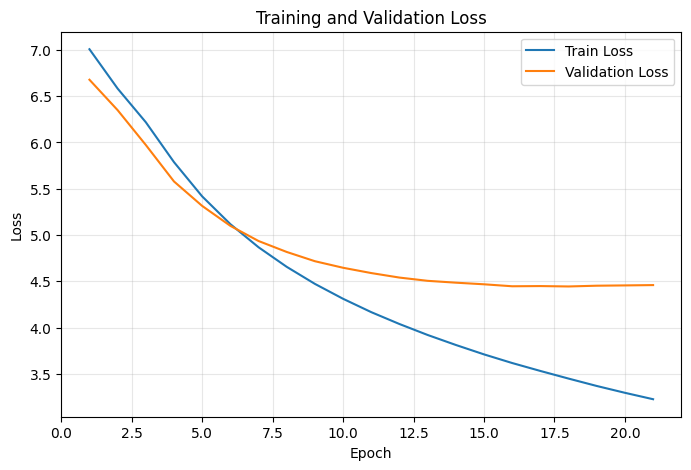

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_loss"], label="Train Loss")
plt.plot(history["epoch"], history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [26]:
def seq2text(input_seq):
    words = []
    for token_idx in input_seq:
        token_idx = int(token_idx)
        if token_idx != 0:
            words.append(src_index_to_word.get(token_idx, "<UNK>"))
    return " ".join(words)


def seq2summary(input_seq):
    words = []
    sos_idx = tar_word_to_index["sostoken"]
    eos_idx = tar_word_to_index["eostoken"]
    for token_idx in input_seq:
        token_idx = int(token_idx)
        if token_idx not in (0, sos_idx, eos_idx):
            words.append(tar_index_to_word.get(token_idx, "<UNK>"))
    return " ".join(words)


def choose_non_unk_token(logits_1d, invalid_token_indices, eos_idx):
    """UNK/PAD/SOS가 1순위일 때 확률순으로 다음 실제 단어를 고릅니다."""
    ranked_token_indices = torch.argsort(logits_1d, descending=True)
    top_token_idx = int(ranked_token_indices[0].item())

    if top_token_idx == eos_idx:
        return eos_idx

    for token_idx in ranked_token_indices.tolist():
        token_idx = int(token_idx)
        if token_idx not in invalid_token_indices:
            return token_idx

    return None


def decode_sequence(input_seq, model, tar_word_to_index, tar_index_to_word, summary_max_len, device):
    model.eval()

    if not torch.is_tensor(input_seq):
        input_seq = torch.tensor(input_seq, dtype=torch.long)
    if input_seq.dim() == 1:
        input_seq = input_seq.unsqueeze(0)
    input_seq = input_seq.to(device).long()

    sos_idx = tar_word_to_index["sostoken"]
    eos_idx = tar_word_to_index["eostoken"]
    pad_idx = tar_word_to_index["<PAD>"]
    unk_idx = tar_word_to_index["<UNK>"]
    invalid_token_indices = {pad_idx, sos_idx, unk_idx, eos_idx}

    decoded_words = []

    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(input_seq)
        decoder_input = torch.tensor([[sos_idx]], dtype=torch.long, device=device)

        for _ in range(summary_max_len - 1):
            logits, hidden, cell, _ = model.decode_step(decoder_input, hidden, cell, encoder_outputs)
            next_token_idx = choose_non_unk_token(
                logits[0, -1, :],
                invalid_token_indices=invalid_token_indices,
                eos_idx=eos_idx,
            )

            if next_token_idx is None or next_token_idx == eos_idx:
                break

            decoded_words.append(tar_index_to_word.get(next_token_idx, "<UNK>"))
            decoder_input = torch.tensor([[next_token_idx]], dtype=torch.long, device=device)

    return " ".join(decoded_words)

In [27]:
if best_model_path.exists():
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    print("새 vocab 설정에 맞는 best model을 불러왔습니다:", best_model_path)
else:
    print("새 vocab 설정에 맞는 best model이 없습니다. 위 학습 셀을 실행해 새 checkpoint를 먼저 저장하세요.")
    print("기존 best_seq2seq_attention_src20000_tar8000.pt 또는 best_seq2seq_attention.pt는 현재 vocab 크기와 맞지 않아 자동 로드하지 않습니다.")

새 vocab 설정에 맞는 best model을 불러왔습니다: best_seq2seq_attention_src30000_tar12000.pt


In [28]:
rows = []
num_samples = min(5, len(encoder_input_val))

for i in range(num_samples):
    generated_summary = decode_sequence(
        encoder_input_val[i],
        model,
        tar_word_to_index,
        tar_index_to_word,
        summary_max_len,
        device,
    )
    rows.append({
        "원문 text 일부": str(raw_text_val[i])[:250],
        "실제 headlines": str(raw_headlines_val[i]),
        "모델 생성 요약문": generated_summary,
    })

abstractive_results = pd.DataFrame(rows)
display_full_dataframe(abstractive_results)

,원문 text 일부,실제 headlines,모델 생성 요약문
0,"Japanese conglomerate Toshiba on Wednesday agreed to sell its flash memory chip business to a consortium led by Bain Capital Private Equity. Toshiba, the world's second-largest producer of NAND memory chips, said the deal was worth about $18 billion.",Toshiba to sell chip business to Bain-led group for $18 bn,japan firm to sell 1 million for its own company business
1,"Apple employees are reportedly walking into doors at its 'Apple Park' office in California, US. The campus' ring-shaped, 2.8 million-square-foot main building is covered entirely in the world's largest panels of curved glass. Employees also tried sti",Apple employees slamming into glass doors at campus: Reports,apple employees to be built in apple factory for us probe
2,"After 13 people were killed in police firing during protests against the Sterlite plant in Tuticorin, writers, journalists, and members of Tamil Nadu film industry staged a protest in Chennai on Saturday. ""The present rulers of Centre and State are b",Journalists protest over deaths during Sterlite protests,sterlite body protests over sterlite plant closure of govt
3,"Don Bradman hit his first-class career's 100th hundred, playing in his 295th innings for an Australian XI against an Indian side on November 15, 1947. Bradman hit 172 runs in the first innings, becoming the first Australian to score 100 first-class c",Bradman's 100th first-class hundred came against an Indian side,bradman fastest to hit 3 000 tons in a test match
4,Several University of Mumbai colleges have decided to start holding lectures for law and Post Graduate courses for the next semester without waiting for the results to be declared. College authorities said this was done so that teachers can complete,"Mumbai colleges to start law, PG classes without results",mumbai university to be shut on new year eve in 2019


### 추상적 요약 결과

이 copy 노트북은 UNK 문제를 완화하기 위해 `src_vocab_limit=30000`, `tar_vocab_limit=12000`으로 키웠습니다. 

비교표에서는 원문과 실제 headline을 정수 인코딩에서 되돌린 값이 아니라 raw 문자열로 보여줍니다. 그래서 실제 headline에는 `<UNK>`가 섞이지 않고, 모델 생성 요약문은 non-UNK fallback이 적용된 생성 결과로 확인할 수 있습니다.

vocab을 기존 8000->20000->30000 / 2000->8000->12000으로 대폭 늘리고 UNK를 그 다음으로 확률이 높은 단어로 대체함으로써 회피해 일단은 읽을 수 있는 것을 만들어 보게 했는데, 결과가 썩 좋지 않다는 것만 다시 한번 확인하게 되었다. 

---    
Summa를 이용한 추출적 요약

추출적 요약은 새로운 문장을 생성하지 않고 원문 안에 있던 문장 중 중요하다고 판단한 문장을 선택(발췌)

In [29]:
from summa.summarizer import summarize


def extractive_summary(text, ratio=0.4, words=20):
    text = str(text).strip()
    if not text:
        return ""

    try:
        result = summarize(text, ratio=ratio)
        if not result.strip():
            result = summarize(text, words=words)
    except ValueError:
        result = ""

    if not result.strip():
        sentences = re.split(r"(?<=[.!?])\s+", text)
        result = sentences[0] if sentences else text[:200]

    return result.strip()

In [30]:
extractive_source = raw_text_for_extractive.loc[data.index]
extractive_rows = []

for idx, text in extractive_source.head(5).items():
    extractive_rows.append({
        "원문 text 일부": text[:300],
        "추출적 요약": extractive_summary(text, ratio=0.4, words=20),
    })

extractive_results = pd.DataFrame(extractive_rows)
display_full_dataframe(extractive_results)

,원문 text 일부,추출적 요약
0,"Saurav Kant, an alumnus of upGrad and IIIT-B's PG Program in Machine learning and Artificial Intelligence, was a Sr Systems Engineer at Infosys with almost 5 years of work experience. The program and upGrad's 360-degree career support helped him transition to a Data Scientist at Tech Mahindra with 9",upGrad's Online Power Learning has powered 3 lakh+ careers.
1,"Kunal Shah's credit card bill payment platform, CRED, gave users a chance to win free food from Swiggy for one year. Pranav Kaushik, a Delhi techie, bagged this reward after spending 2000 CRED coins. Users get one CRED coin per rupee of bill paid, which can be used to avail rewards from brands like","Users get one CRED coin per rupee of bill paid, which can be used to avail rewards from brands like Ixigo, BookMyShow, UberEats, Cult.Fit and more."
2,New Zealand defeated India by 8 wickets in the fourth ODI at Hamilton on Thursday to win their first match of the five-match ODI series. India lost an international match under Rohit Sharma's captaincy after 12 consecutive victories dating back to March 2018. The match witnessed India getting all ou,"The match witnessed India getting all out for 92, their seventh lowest total in ODI cricket history."
3,"With Aegon Life iTerm Insurance plan, customers can enjoy tax benefits on your premiums paid and save up to â¹46,800^ on taxes. The plan provides life cover up to the age of 100 years. Also, customers have options to insure against Critical Illnesses, Disability and Accidental Death Benefit Rider w","Also, customers have options to insure against Critical Illnesses, Disability and Accidental Death Benefit Rider with a life cover up to the age of 80 years."
4,"Speaking about the sexual harassment allegations against Rajkumar Hirani, Sonam Kapoor said, ""I've known Hirani for many years...What if it's not true, the [#MeToo] movement will get derailed."" ""In the #MeToo movement, I always believe a woman. But in this case, we need to reserve our judgment,"" she","Speaking about the sexual harassment allegations against Rajkumar Hirani, Sonam Kapoor said, ""I've known Hirani for many years...What if it's not true, the [#MeToo] movement will get derailed."" ""In the #MeToo movement, I always believe a woman."


일단 무언가 '읽을 수 있는 것'을 생성한 점에서는 추출적 요약이 훨씬 나아보이나.. 이것도 그렇게 요약을 잘 해주진 못하는것 같다. 

어지럽다..